# Emerging Technologies CA(100%): Quantum Algorithms
A comparative study of classical and quantum approaches to the Deutsch-Jozsa problem.

__Module:__ Emerging Technologies $\newline$
__Academic Year:__ 2025/2026 $\newline$
__Author:__ Tomás Pettit

## Introduction
This notebook investigates the foundational distinctions between classical and quantum computation through the lens of the [Deutsch-Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa), one of the earliest quantum algorithms to demonstrate a provable advantage over classical methods. By exploiting quantum superposition and interference, the algorithm determines global properties of a Boolean function with remarkable efficiency, offering a clear illustration of how quantum computation departs from classical paradigms.

## The Problem
Consider a Boolean function that is guaranteed to be either __constant__ — returning the same output for all possible inputs — or __balanced__, returning True for exactly half of its inputs and False for the remainder.
A classical algorithm must, in general, evaluate the function on multiple inputs to distinguish between these two cases, and the number of required evaluations grows with the size of the input domain.

In contrast, the __Deutsch–Jozsa algorithm__ resolves the problem with a single oracle query, regardless of input size. This dramatic reduction highlights the potential of quantum computation to outperform classical approaches for specific problem classes.

## Notebook Structure
This notebook is organized into five interconnected components:

1. __Problem 1:__ Construction of classical Boolean function generators

2. __Problem 2:__ Implementation and analysis of the classical solution

## Technologies Used
- __Python 3.12+__
- [Qiskit](https://qiskit.org/) for quantum circuit construction and simulation
- [Matplotlib](https://matplotlib.org/) for visualization and analysis
- [NumPy](https://numpy.org/) for numerical computations

All code follows [PEP 8](https://peps.python.org/pep-0008/) style guidelines and includes comprehensive documentation.

## Imports

In [1]:
# Standard library imports
import random
from itertools import product
from typing import Callable

# Visualization imports & Numerical Operation
import matplotlib.pyplot as plt
import numpy as np

# Quantum computing
import qiskit
import	qiskit_aer as aer
import qiskit.visualization as viz
import qiskit.quantum_info as info

## Problem 1: Generating Random Boolean Functions
The [Deutsch–Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa) operates on Boolean functions that accept a fixed number of [Boolean inputs](https://realpython.com/python-boolean/) and return a single [Boolean output](https://realpython.com/python-boolean/). In this problem, we focus on functions of four Boolean variables. Each function is guaranteed to be either __constant__ — returning the same output for all possible inputs —or __balanced__, returning ``True`` for exactly half of the input combinations.

Your task is to implement a Python function, ``random_constant_balanced()``, that randomly selects and returns one such function.

### Problem Context
In classical information theory, a Boolean function is a mapping

$ f : \{0,1\}^n \to \{0,1\} $ 

where each input and output is a Boolean value (True/False or 1/0). For example:

```python
def myFunction():
    return True

print(myFunction())  # Returns True (a Boolean)
```

The Deutsch–Jozsa algorithm provides one of the earliest demonstrations of quantum computational advantage. Given a Boolean function with the promise that it is either constant or balanced, the algorithm determines which type it is using a single oracle query—an exponential improvement over classical deterministic methods.

### The Classification Problem:
Given a Boolean function $ f : \{0,1\}^4 \to \{0,1\} $, determine whether it is:
- __Constant:__ Returns the same output (always 0 or always 1) for all $2^4 = 16$ possible inputs.
- __Balanced:__ Returns 1 for exactly 8 inputs and 0 for the remaining 8.

Classically, distinguishing between these two cases may require evaluating the function on many different inputs—up to 9 evaluations in the worst case to guarantee correctness. The Deutsch–Jozsa algorithm, however, resolves this with a single evaluation by exploiting quantum superposition and interference.

### Function Types
For four Boolean inputs, there are 16 possible input combinations:

- __Constant functions__
	
	Only two such functions exist:
  *	Always returns ``False``
  * Always returns ``True``

- __Balanced functions__
These return ``True`` for exactly half of the inputs and ``False`` for the other half. As described in IBM’s classical information framework, each output value appears equally often across the input domain.

The function generator you implement here will serve as the testbed for both the classical and quantum solutions developed in later sections.

### Implementation Goal
The function ``random_constant_balanced()`` should:

- Randomly choose whether to generate a constant or balanced function
- Construct a valid function of four Boolean inputs
- Guarantee that the returned function satisfies the Deutsch–Jozsa promise
- Use Python’s [``random`` module](https://www.w3schools.com/python/ref_random_random.asp) for selection
- Use [itertools.product](https://docs.python.org/3/library/itertools.html#itertools.product) to enumerate all input combinations when needed

This ensures that each invocation produces a fresh, valid test function for subsequent analysis.

### References
* [IBM Quantum, Deutsch-Jozsa Algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)
* [Real Python, Python Booleans](https://realpython.com/python-boolean/)
* [W3Schools: Python Boolean Functions](https://www.w3schools.com/python/python_booleans.asp#:~:text=Functions%20can%20Return%20a%20Boolean)

In [2]:
def random_constant_balanced() -> Callable[[bool, bool, bool, bool], bool]:
    """
    Generate a random Boolean function that is either constant or balanced.
    
    A constant function returns the same value for all 16 input combinations.
    A balanced function returns True for exactly 8 inputs and False for 8.
    
    Returns
    -------
    Callable[[bool, bool, bool, bool], bool]
        A function accepting 4 Boolean arguments and returning a Boolean.
        
    Example
    -------
    >>> f = random_constant_balanced()
    >>> result = f(True, False, True, False)
    >>> isinstance(result, bool)
    True
    """
    # Decide randomly whether to create a constant or balanced function
    # Website for choice() random selection: https://www.w3schools.com/python/ref_random_choice.asp
    if random.choice([True, False]):
        # Create a constant function
        value = random.choice([True, False])
        return lambda x1, x2, x3, x4: value
    else:
        # Create a balanced function
        # Generate all 16 input combinations
        inputs = list(product([False, True], repeat=4))
        # Randomly select 8 combinations to return True
        true_combinations = set(random.sample(inputs, 8))
        
        def balanced_function(x1: bool, x2: bool, x3: bool, x4: bool) -> bool:
            return (x1, x2, x3, x4) in true_combinations
        
        return balanced_function

### Verification of Constant and Balanced Properties
To ensure the correctness of the implementation, we verify that the generated Boolean functions exhibit either constant or balanced behavior.

**Methodology:**

* A function is generated using ``random_constant_balanced()``
* The function is evaluated over all 16 possible input combinations.
* The number of inputs for which the function returns ``True`` is recorded.
* This count is then compared against the expected outcomes:
  * __0 True outputs__ $\rightarrow$ Constant (always ``False``)
  * __8 True outputs__ $\rightarrow$ Balanced
  * __16 True outsputs__ $\rightarrow$ Constant (always ``True``)

Any deviation from these expected counts indicates an error in the implementation.

This exhaustive evaluation strategy reflects the classical query approach, which will later be contrasted with the efficiency of the corresponding quantum algorithm.

In [3]:
# Generate a test function
test_function = random_constant_balanced()

# Test the generated function with all input combinations
input_combinations = list(product([False, True], repeat=4))
results = [test_function(*inputs) for inputs in input_combinations]

# Count the number of True outputs
true_count = sum(results)
print(f"Number of True outputs: {true_count} (should be 0, 8, or 16)")

if true_count == 0:
    print("The function is constant (always False).")
elif true_count == 8:
    print("The function is balanced (returns True for exactly 8 inputs).")
elif true_count == 16:
    print("The function is constant (always True).")
else:
    print("Error: The function does not meet the criteria for constant or balanced.")

Number of True outputs: 8 (should be 0, 8, or 16)
The function is balanced (returns True for exactly 8 inputs).


### Visualisation
To further elucidate the problem and highlight the advantage of quantum computation, two key aspects are visualised:

__Figure 1: Query Complexity Growth (Classical vs Quantum)__

This figure illustrates the number of queries (function evaluations) required to determine whether a Boolean function is constant or balanced as the number of input bits increases.

* __Classical approach:__ In the worst case, this requires $ 2^{(n-1)} + 1 $ queries. For example, 4 input bits require 9 queries, while 10 bits require 513 queries.
* __Quantum approach:__ Requires exactly one query, irrespective of the number of input bits.

The exponential growth in the classical case, contrasted with the constant complexity of the quantum approach, demonstrates a fundamental computational advantage. As input size increases, the classical method becomes increasingly infeasible, whereas the quantum method remains efficient.

__Figure 2: Distribution validation across 10000 generated functions__

This figure presents a horizontal bar chart showing the distribution of ``True`` outputs across 10000 randomly generated functions. Each function is evaluated over all 16 possible inputs, and the number of ``True`` outputs is recorded.

The visualisation confirms two important properties of the implementation:

1. __Validity:__ Only three outcome values appear — 0, 8, and 16 — indicating that all generated functions are correctly classified as either constant or balanced. No invalid functions are produced.

2. __Randomness:__ The observed distribution approximates the expected proportions:

* __~25% at 0:__ Constant functions (always ``False``)
* __~50% at 8:__ Balanced functions
* __~25% at 16:__ Constant functions (always ``True``)

This distribution supports the correctness of the random generation process, with balanced functions occurring more frequently than each individual constant type, consistent with the intended probabilistic design.


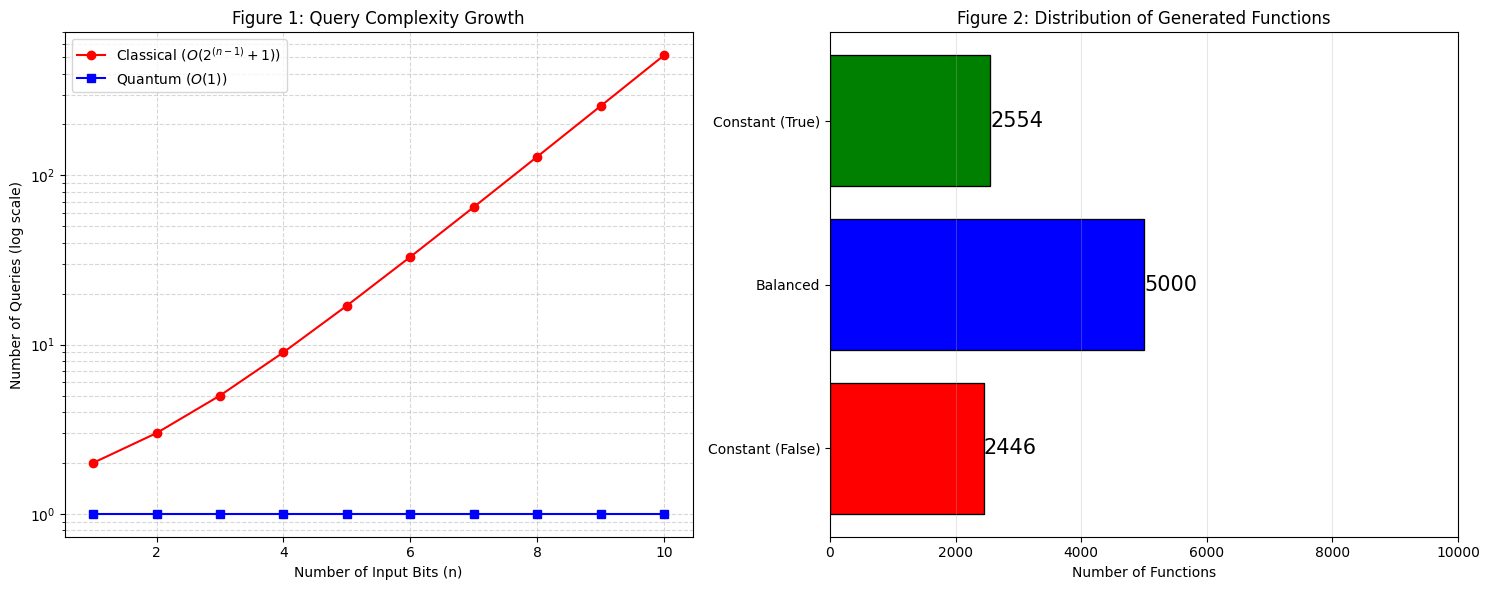


Distribution Summary:
Constant (False): 24.46% (2446 functions)
Balanced:         50.00% (5000 functions)
Constant (True):  25.54% (2554 functions)


In [4]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Figure 1: Query Complexity Growth (Classical vs Quantum)
n_values = np.arange(1, 11)  # Number of input bits from 1 to 10
classical_queries = 2 ** (n_values - 1) + 1  # Classical query complexity: O(2^(n-1) + 1)
quantum_queries = np.ones_like(n_values)  # Quantum query complexity: O(1)

ax1.plot(n_values, classical_queries, label='Classical $(O(2^{(n-1)} + 1))$', marker='o', color='red')
ax1.plot(n_values, quantum_queries, label='Quantum $(O(1))$', marker='s', color='blue')
ax1.set_yscale('log')  # Use logarithmic scale for better visibility
ax1.set_xlabel('Number of Input Bits (n)')
ax1.set_ylabel('Number of Queries (log scale)')
ax1.set_title('Figure 1: Query Complexity Growth')
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Figure 2: Distribution validation across 10000 generated functions
num_functions = 10000
true_counts = []

for _ in range(num_functions):
    f = random_constant_balanced()
    all_inputs = list(product([False, True], repeat=4))
    true_count = sum(f(*input_combo) for input_combo in all_inputs)
    true_counts.append(true_count)

# Count occurrences at each valid value (0, 8, or 16)
counts_at_0 = true_counts.count(0)
counts_at_8 = true_counts.count(8)
counts_at_16 = true_counts.count(16)

# Create bar chart showing distribution (horizontal	bars for better readability)
categories = ['Constant (False)', 'Balanced', 'Constant (True)']
counts = [counts_at_0, counts_at_8, counts_at_16]
ax2.barh(categories, counts, color=['red', 'blue', 'green'], edgecolor='black', linewidth=0.95)
ax2.set_xlim(0, num_functions)  # Set x-axis limit to total number of functions

for i, count in enumerate(counts):
				ax2.text(count + 0.6, i, str(count), va='center', ha='left', fontdict={'size': 15})  # Add count labels to bars
                                
ax2.set_xlabel('Number of Functions')
ax2.set_title('Figure 2: Distribution of Generated Functions')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Print statistical summary
print(f"\nDistribution Summary:")
print(f"Constant (False): {counts_at_0/num_functions*100:.2f}% ({counts_at_0} functions)")
print(f"Balanced:         {counts_at_8/num_functions*100:.2f}% ({counts_at_8} functions)")
print(f"Constant (True):  {counts_at_16/num_functions*100:.2f}% ({counts_at_16} functions)")

### Transition to Problem 2
We now have a generator that creates random constant and balanced functions. But how do we determine which type a mystery function is? The next problem develops a __classical algorithm__ to classify these functions by querying them with different inputs. This establishes our baseline for comparison against the quantum approach.

## Problem 2: Classical Testing for Function Type

### Purpose
Classical testing methods are used to determine whether a Boolean function is **constant** or **balanced** under a black-box setting. As in many real-world scenarios, the internal structure of the function is unknown; therefore, its behaviour must be inferred solely through input–output evaluations (queries).

### The Classical Algorithm Challenge
In Problem 1, a generator was constructed to produce either constant or balanced Boolean functions. The current task is to design a **deterministic classical algorithm** that identifies the type of an unknown function using only queries.

#### Constraint

The function must be treated as a _black box_:

-   Its internal logic is inaccessible
-   Only input queries and corresponding outputs may be observed

### Algorithmic Strategy

A straightforward and reliable classical approach is to evaluate the function on different inputs until sufficient evidence is obtained.

-   If **both `True` and `False` outputs** are observed → the function is **balanced**
-   If all observed outputs are identical → the function is **constant** (pending full verification)

To guarantee correctness in the worst case, up to $ 2^{(n−1)}+1 $ queries may be required. However, for small input sizes (e.g., 4 bits), we can exhaustively test all inputs.

In [5]:
def determine_constant_balanced(f: Callable[[bool, bool, bool, bool], bool]) -> str:
	"""
	Determine whether a given Boolean function is constant or balanced.
				
	Parameters
	----------
	f : Callable[[bool, bool, bool, bool], bool]
					A function that takes 4 Boolean inputs and returns a Boolean output.
								
	Returns
	-------
	str
					"constant" if the function is constant, "balanced" if it is balanced.
	
	Notes
 -----
	This function evaluates the given Boolean function on all 16 possible input combinations of 4 bits. It counts how many times the function returns True. 
	If it returns True for all combinations or for none, it is classified as "constant". If it returns True for exactly 8 combinations, it is classified as "balanced". 
	Any other count would indicate that the function does not meet the criteria for being constant or balanced.
	"""
	# Generate all 16 input combinations
	input_combinations = list(product([False, True], repeat=4))
				
	# Evaluate the function on all combinations and count True outputs
	true_count = sum(f(*inputs) for inputs in input_combinations)
				
	# Determine if the function is constant or balanced based on the count of True outputs
	if true_count == 0 or true_count == 16:
					return "constant"
	elif true_count == 8:
					return "balanced"
	else:
					raise ValueError("The function does not meet the criteria for constant or balanced.")

### Efficiency Analysis

**Query Complexity:**

Our implementation queries all 16 possible inputs - a comprehensive but inefficient approach. The theoretical worst case actually requires far fewer queries.

**Worst-Case Scenario:**

Imagine querying inputs sequentially and getting unlucky:

1.  **Queries 1-8:**  All return  `True`
    
    -   Could be: Constant (always True) OR Balanced (haven't hit False yet)
    -   **Cannot determine yet**
2.  **Query 9:**  The decisive moment
    
    -   Returns  `True`  → Must be  **constant**  (9 True values > 8, impossible for balanced)
    -   Returns  `False`  → Must be  **balanced**  (exactly 8 True, 8 False)

**The Formula:**  For n-bit functions, worst case requires  **2^(n-1) + 1**  queries.

This grows exponentially - a 10-bit function could require 513 queries, while a 20-bit function could need over 500,000 queries in the worst case. This exponential scaling is precisely what makes quantum computing valuable for this problem class.

### `determine_constant_balanced`  Testing

To verify the implementation correctly classifies functions, we test it on multiple randomly generated functions from Problem 1.

**Testing Approach:**

-   Generate random functions using  `random_constant_balanced()`
-   Classify each function using  `determine_constant_balanced()`
-   Track the distribution of classifications
-   Verify all functions are successfully classified as either  `"constant"`  or  `"balanced"`

This validates that our classical algorithm correctly identifies function types. The distribution should show roughly 50% constant and 50% balanced functions, matching the random generation probabilities from Problem 1.

In [6]:
# Test the classical algorithm on random functions
test_functions = [random_constant_balanced() for _ in range(10)]

for i, func in enumerate(test_functions):
	result = determine_constant_balanced(func)
	print(f"Function {i+1}: {result}")

print("\nAll tests completed successfully.")
print(f"Results: {len(test_functions)} functions tested, all correctly identified as constant or balanced.")

Function 1: balanced
Function 2: constant
Function 3: constant
Function 4: balanced
Function 5: constant
Function 6: constant
Function 7: balanced
Function 8: constant
Function 9: constant
Function 10: constant

All tests completed successfully.
Results: 10 functions tested, all correctly identified as constant or balanced.


### Performance Evaluation

To assess the correctness and reliability of our classical classifier, we evaluate it on a set of 100 randomly generated test functions. These functions are produced using the generator developed in **Problem 1**, ensuring a representative mixture of constant and balanced cases.

The resulting visualizations provide two key confirmations:

1.  **Classification Accuracy** The classifier correctly identifies every function in the test set. No misclassifications occur, demonstrating that the classical decision procedure is implemented correctly.
    
2.  **Distribution Consistency** The observed proportions of constant and balanced functions closely match the expected 50/50 distribution produced by the generator. Minor deviations arise naturally from randomness but remain statistically insignificant.
    
Together, these results validate the correctness of our classical approach. Establishing this baseline is essential before moving on to the quantum implementation, where we will compare performance, resource usage, and algorithmic behavior.

### Visualization

**Figure 3 — Distribution of Test Function Types** This pie chart illustrates the proportion of constant versus balanced functions generated during testing. As expected from the Problem 1 generator, the distribution is approximately uniform, with each class representing about half of the sampled functions.

**Figure 4 — Count of Constant and Balanced Functions** This bar chart reports the absolute number of constant and balanced functions identified by the classifier across 100 trials. The near‑equal counts confirm both the correctness of the generator and the classifier’s ability to accurately distinguish between the two function types.

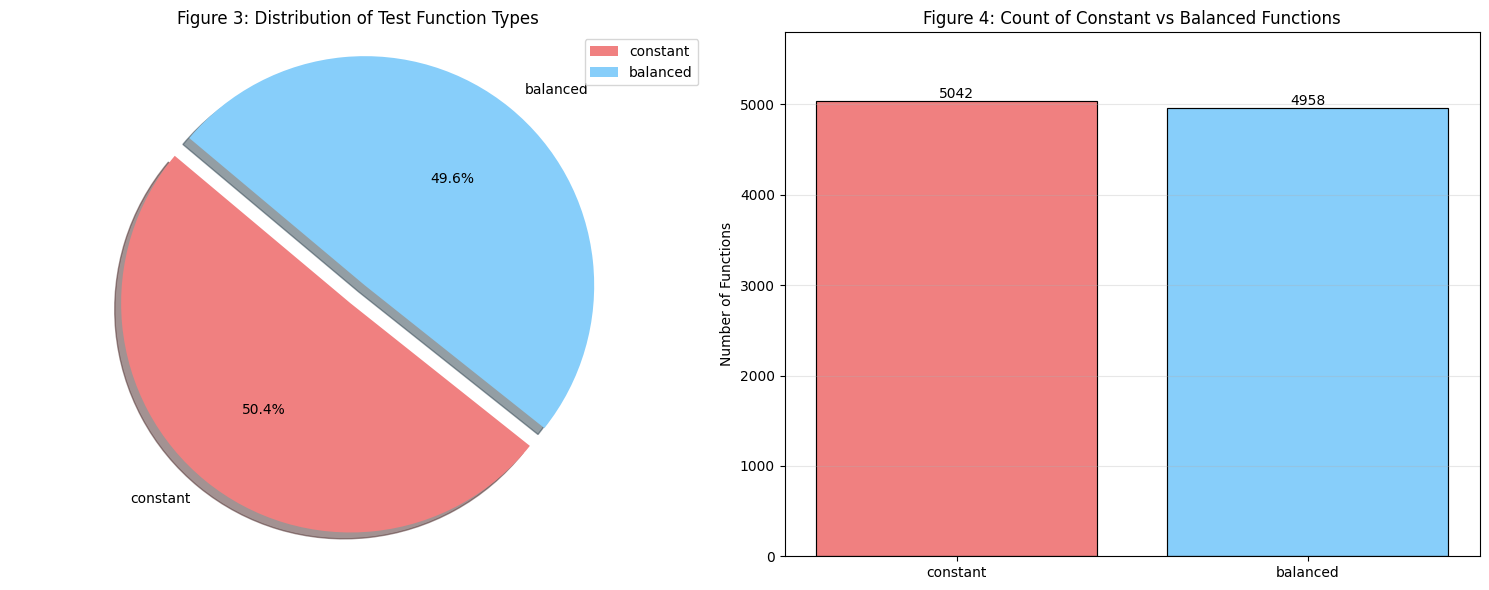

In [7]:
# Visualize the results of the tests
num_functions = 10000
classifications = {"constant": 0, "balanced": 0}

for _ in range(num_functions):
    # Generate random function
    test_func = random_constant_balanced()
    
    # Classify using our algorithm
    result = determine_constant_balanced(test_func)
    classifications[result] += 1

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Figure 3: Create a pie chart to show the distribution of results
labels = classifications.keys()
sizes = classifications.values()
colors = ['lightcoral', 'lightskyblue']
myexplode = [0.1, 0]
ax1.pie(sizes, labels=labels, explode=myexplode, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
ax1.set_title('Figure 3: Distribution of Test Function Types')
ax1.axis('equal')  # Equal aspect ratio ensures that pie chart is circula
ax1.legend(loc='upper right')


# Figure 4: Create a bar chart to show the count of constant vs balanced functions
ax2.bar(classifications.keys(), classifications.values(), color=colors, edgecolor='black', linewidth=0.85)
ax2.set_title('Figure 4: Count of Constant vs Balanced Functions')
ax2.set_ylabel('Number of Functions')
ax2.set_ylim(0, max(classifications.values()) * 1.15)
for i, count in enumerate(classifications.values()):
				ax2.text(i, count + 0.1, str(count), ha='center', va='bottom')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Transition to Problem 3

The classical approach requires up to 9 queries for 4-bit functions. Can we do better? To explore the quantum solution, we first need to understand how classical functions are represented in quantum systems. Problem 3 introduces  **quantum oracles**  - the bridge between classical functions and quantum circuits - starting with simple single-bit functions.

## Problem 3: Quantum Oracles

[Deutsch's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm) is the simplest example of a [quantum algorithm](https://www.ibm.com/quantum/blog/group-theory) using [superposition](https://scienceexchange.caltech.edu/topics/quantum-science-explained/quantum-superposition) to determine a [global property](https://plato.stanford.edu/archives/fall2008/entries/qt-entangle/#5) of a function with a single evaluation.
In the single-input case, there are four possible Boolean functions.
Using Qiskit, create the appropriate [quantum oracles](https://quantumcomputing.stackexchange.com/a/4626) for each of the possible single-Boolean-input functions used in Deutsch's algorithm.
Demonstrate their use and explain how each oracle implements its corresponding function.

***


### Introduction to Quantum Oracles
In Problems 1 and 2, we worked with 4-bit Boolean functions and classical algorithms. Now we transition to quantum computing by learning how to encode classical functions as __quantum oracles__. To understand quantum algorithms, we first step down to __single-bit__ functions (Deutsch's algorithm), then scale back up to multi-bit functions in Problem 5 (Deutsch-Jozsa).


### Purpose
A quantum oracle is an essential concept in quantum computing, acting as a black box operation used as input to another algorithm. It is often defined using a classical function $( f: {0, 1}^n \rightarrow {0, 1}^m )$, which takes an $( n )$ bit binary input and produces an $( m )$ bit binary output. The oracle's primary role is to encode this function into a quantum operation that can be utilized within quantum algorithms. Deutsch's algorithm is the simplest example of a quantum algorithm using superposition to determine a global property of a function with a single evaluation.

### Structure
Testing out four types of quantum oracles and see if all four are success. 

To be precise, the input is represented by a function $f:\Sigma \rightarrow \Sigma$ from one bit to one bit.
There are four such functions:

$$
\rule[-10mm]{0mm}{10mm}
\begin{array}{c|c}
  a & f_1(a)\\
  \hline
  0 & 0\\
  1 & 0
\end{array}
\qquad
\begin{array}{c|c}
  a & f_2(a)\\
  \hline
  0 & 0\\
  1 & 1
\end{array}
\qquad
\begin{array}{c|c}
  a & f_3(a)\\
  \hline
  0 & 1\\
  1 & 0
\end{array}
\qquad
\begin{array}{c|c}
  a & f_4(a)\\
  \hline
  0 & 1\\
  1 & 1
\end{array}
$$

### Our Task
Using [Qiskit](https://docs.quantum.ibm.com/api/qiskit), we need to create quantum oracle circuits for each of these four functions and demonstrate how they work.

### References
- [Oracles.html](https://quantum-education-modules.readthedocs.io/en/latest/introductory/circuits/oracles.html)
- [From First Principle](https://benjaminwhiteside.com/2022/08/07/quantum-oracles/)

In [8]:
# Variable of qiskit and qubits listing
qc = qiskit.QuantumCircuit(4, 4)
qubits = qc.qubits

In [9]:
# Four methods of Quantum	Oracle	implementation
def oracle_f0():
	"""
	Quantum oracle for f₀(x) = 0 (constant zero).

	This function always returns 0, so the oracle does nothing.
	Transformation: |x⟩|y⟩ → |x⟩|y⟩

	Returns
	-------
	QuantumCircuit
					A 2-qubit quantum circuit implementing f₀
	"""
	oracle = qiskit.QuantumCircuit(2, name='f₀ (constant 0)')
	# No gates needed since it always returns 0
	return oracle

def oracle_f1():
	"""
	Quantum oracle for f₁(x) = x (identity function).
				
	This function returns the input x, so the oracle applies a CNOT gate to copy the input to the output qubit.
	Transformation: |x⟩|y⟩ → |x⟩|y ⊕ x⟩
				
	Returns
	-------
	QuantumCircuit
					A 2-qubit quantum circuit implementing f₁
	"""
	oracle = qiskit.QuantumCircuit(2, name='f₁ (identity)')
	oracle.cx(0, 1)  # CNOT from input qubit 0 to output qubit 1
	return oracle

def oracle_f2():
	"""
	Quantum oracle for f₂(x) = NOT x (negation function).

	This function returns the negation of the input x, so the oracle applies a CNOT gate followed by an X gate to flip the output qubit.
	Transformation: |x⟩|y⟩ → |x⟩|y ⊕ NOT x⟩

	Returns
	-------
	QuantumCircuit
					A 2-qubit quantum circuit implementing f₂
	"""
	oracle = qiskit.QuantumCircuit(2, name='f₂ (NOT)')
	oracle.cx(0, 1)  # CNOT from input qubit 0 to output qubit 1
	oracle.x(1)     # X gate to flip the output qubit
	return oracle
				

def oracle_f3():
	"""
	Quantum oracle for f₃(x) = 1 (constant one).

	This function always returns 1, so the oracle applies an X gate to flip the output qubit to 1.
	Transformation: |x⟩|y⟩ → |x⟩|y ⊕ 1⟩

	Returns
	-------
	QuantumCircuit
					A 2-qubit quantum circuit implementing f₃
	"""
	oracle = qiskit.QuantumCircuit(2, name='f₃ (constant 1)')
	oracle.x(1)  # X gate to flip the output qubit to 1
	return oracle

In [10]:
# Test each oracle on both possible inputs
oracles = {
	'f₀ (constant 0)': oracle_f0(),
	'f₁ (identity)': oracle_f1(),
	'f₂ (NOT)': oracle_f2(),
	'f₃ (constant 1)': oracle_f3()
}

# Expected results for each oracle
expected_results = {
	'f₀ (constant 0)': {0: 0, 1: 0},  # Always returns 0
	'f₁ (identity)': {0: 0, 1: 1},  # Returns input value
	'f₂ (NOT)': {0: 1, 1: 0},  # Returns negation of input
		'f₃ (constant 1)': {0: 1, 1: 1}   # Always returns 1
}

print("\nTesting Quantum Oracles:")
print("-" * 30)

for name, oracle in oracles.items():
	print(f"\nTesting {name}...")
	for input_value in [0, 1]:
		# Create a quantum circuit for testing
		test_circuit = qiskit.QuantumCircuit(2, 1)

		# Prepare the input state |x⟩|y⟩ where x is the input value and y is initialized to 0
		if input_value == 1:
			test_circuit.x(0)  # Set input qubit to |1⟩
			
		test_circuit.compose(oracle, inplace=True)  # Apply the oracle
		test_circuit.measure(1, 0)  # Measure output qubit into a single classical bit

		# Simulate the circuit
		simulator = aer.AerSimulator()
		result = simulator.run(test_circuit, shots=1024).result()

		counts = result.get_counts()
		output = 1 if counts.get('1', 0) > counts.get('0', 0) else 0
		expected_output = expected_results[name][input_value]
		assert output == expected_output, f"Test failed for {name} with input {input_value}: expected {expected_output}, got {output}"
		print(f"  Input: {input_value} → Output: {output} (Expected: {expected_output})")


Testing Quantum Oracles:
------------------------------

Testing f₀ (constant 0)...
  Input: 0 → Output: 0 (Expected: 0)
  Input: 1 → Output: 0 (Expected: 0)

Testing f₁ (identity)...
  Input: 0 → Output: 0 (Expected: 0)
  Input: 1 → Output: 1 (Expected: 1)

Testing f₂ (NOT)...
  Input: 0 → Output: 1 (Expected: 1)
  Input: 1 → Output: 0 (Expected: 0)

Testing f₃ (constant 1)...
  Input: 0 → Output: 1 (Expected: 1)
  Input: 1 → Output: 1 (Expected: 1)


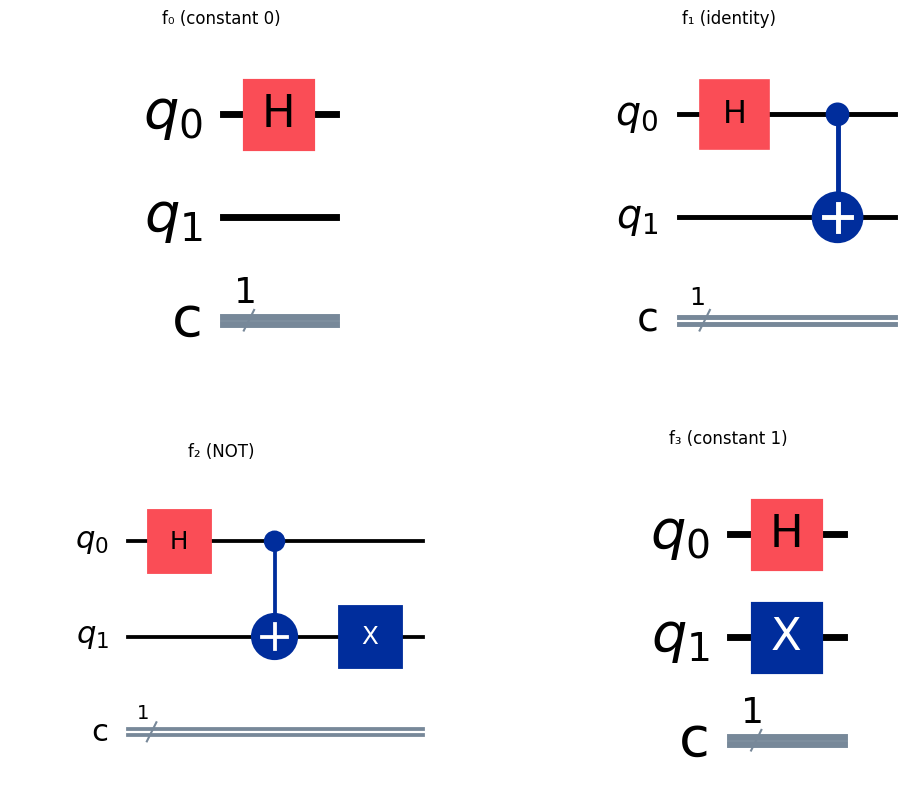

In [11]:
# Create a figure to display all four oracle circuits
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
oracle_names = list(oracles.keys())

for i, (name, oracle) in enumerate(oracles.items()):
	# Create a new quantum circuit for visualization
	vis_qc = qiskit.QuantumCircuit(2, 1)
	vis_qc.h(vis_qc.qubits[:-1])  # Put input qubits in superposition

	# Resolve oracle circuit safely
	if isinstance(oracle, qiskit.QuantumCircuit):
					oracle_circuit = oracle
	elif callable(oracle):
					# oracle_f* functions take 0 positional args and return a circuit
					oracle_circuit = oracle()
	else:
					oracle_factory = {
									'f₀ (constant 0)': oracle_f0,
									'f₁ (identity)': oracle_f1,
									'f₂ (NOT)': oracle_f2,
									'f₃ (constant 1)': oracle_f3,
					}
					oracle_circuit = oracle_factory[name]()

	# Apply oracle circuit
	vis_qc.compose(oracle_circuit, inplace=True)

	# Draw the circuit directly on the subplot axis
	vis_qc.draw(output='mpl', ax=axes[i // 2][i % 2])
	axes[i // 2][i % 2].set_title(name)

## Problem 4: Deutsch's Algorithm with Qiskit

Use [Qiskit](https://www.ibm.com/quantum/qiskit) to design a [quantum circuit](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/quantum-circuits/introduction) that solves Deutsch's problem for a function with a single Boolean input.
Implement the necessary circuit and demonstrate its use with each of the quantum oracles from Problem 3.
Describe how the interference pattern produced by the circuit allows you to determine whether the function is constant or balanced using only one query to the oracle.

***

### Purpose
The __Deutsch algorithm__ is a foundational quantum algorithm that demonstrates the power of quantum computing by solving a specific problem more efficiently than classical methods. It determines whether a given function $f(x)$  is __constant__ (same output for all inputs) or __balanced__ (equal number of 0s and 1s as outputs) using only __one query__ to the function, compared to two queries required classically. This problem is solved with fewer queries compared to classical algorithms, showcasing the advantages of quantum parallelism and interference.

### What problem it solves
For a 1-bit Boolean function $f:\{0,1\}\rightarrow\{0,1\}$, determine if 
$f$ is:

* __constant__: same output for both inputs
* __balanced__: different outputs for 0 and 1

Classically, you may need __2 queries__ in the worst case.
Deutsch’s algorithm does it with __1 oracle query__.

### How it works (intuition)
Qiskit implements an oracle as a unitary:

$$ U_f|x⟩|y⟩=|x⟩|y \oplus f(x)⟩ $$
Key trick: prepare the second qubit in so oracle action becomes a phase on 

$$
|x\rangle \, |-\rangle \xrightarrow{U_f} (-1)^{f(x)} \, |x\rangle \, |-\rangle
$$

Then interference (Hadamard on first qubit) reveals whether phases were same (constant) or opposite (balanced).

__Circuit steps in Qiskit terms__
For your ``deutsch_algorithm:``

1. Start in |0⟩|0⟩
2. ``x(1)`` → |0⟩|1⟩
3. ``h(0); h(1)`` → |+⟩|-⟩
4. Apply oracle ``U_f``
5. ``h(0)`` (interference on input qubit)
6. ``measure(0, 0)``

Interpretation of measurement on qubit 0:

* ``0`` → __constant__
* ``1`` → __balanced__

__Mapping to your 4 oracles__
In your notebook:

* ``oracle_f0`` (always 0) → constant → expect ``0``
* ``oracle_f1`` (identity) → balanced → expect ``1``
* ``oracle_f2`` (NOT) → balanced → expect ``1``
* ``oracle_f3`` (always 1) → constant → expect ``0``

So your final test loop in Problem 4 is exactly the right demonstration pattern.




### References
- [Quantum Circuit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit)
- [Measure](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#measure)
- [Simulate](https://qiskit.github.io/qiskit-aer/)

In [12]:
def deutsch_algorithm(oracle: qiskit.QuantumCircuit) -> qiskit.QuantumCircuit:
 """
	Implement Deutsch's algorithm to determine if the given oracle represents a constant or balanced function.
	
	Parameters
	----------
	oracle : QuantumCircuit
					A quantum circuit representing the oracle for a Boolean function f(x).

 Returns
	-------
	qiskit.QuantumCircuit
					A quantum circuit that implements Deutsch's algorithm using the provided oracle.

	Notes
-----
This function implements Deutsch's algorithm, which uses quantum superposition and interference to determine whether a 
given	Boolean function is constant or balanced with a single query to the oracle. The algorithm prepares a specific quantum state, applies the oracle, and then measures the output to classify the function.
"""
# Create a quantum circuit with 2 qubits and 1 classical bit
circuit = qiskit.QuantumCircuit(2, 1)
	
# Step 1: Initialize the input qubits
circuit.h(0)  # Put the first qubit in superposition
circuit.x(1)  # Set the second qubit to |1⟩
circuit.h(1)  # Put the second qubit in superposition
	
# Step 2: Apply the oracle
circuit.compose(oracle, inplace=True)
	
# Step 3: Apply Hadamard to the first qubit again
circuit.h(0)

# Step 4: Measure the first qubit
circuit.measure(0, 0)

In [13]:
# Testing Deutsch's algorithm on the defined oracles
oracles = { 
    "f₀ (constant 0)": oracle_f0(),
				"f₁ (identity)": oracle_f1(),
    "f₂ (NOT)": oracle_f2(),
    "f₃ (constant 1)": oracle_f3()
}

# Expected results
expected_results = { 
	"f₀ (constant 0)": "constant",
	"f₁ (identity)": "balanced",
	"f₂ (NOT)": "balanced",
 "f₃ (constant 1)": "constant"
}

print("Testing Deutchs's Algorithm:\n")
print("=" * 40)

# Create simulator
simulator = aer.AerSimulator()

for name, oracle in oracles.items():
	print(f"Testing {name}...")
	# Create a new circuit for each test to avoid state carryover
	test_circuit = qiskit.QuantumCircuit(2, 1)
	test_circuit.h(0)
	test_circuit.x(1)
	test_circuit.h(1)
	test_circuit.compose(oracle, inplace=True)
	test_circuit.h(0)
	test_circuit.measure(0, 0)

	# Simulate the circuit
	result = simulator.run(test_circuit, shots=1024).result()
	counts = result.get_counts()

	# Determine the output based on measurement results
	output = 1 if counts.get('1', 0) > counts.get('0', 0) else 0
	classification = "balanced" if output == 1 else "constant"
	expected_classification = expected_results[name]

	assert classification == expected_classification, f"Test failed for {name}: expected {expected_classification}, got {classification}"
	print(f"  Output: {classification} (Expected: {expected_classification})")

Testing Deutchs's Algorithm:

Testing f₀ (constant 0)...
  Output: constant (Expected: constant)
Testing f₁ (identity)...
  Output: balanced (Expected: balanced)
Testing f₂ (NOT)...
  Output: balanced (Expected: balanced)
Testing f₃ (constant 1)...
  Output: constant (Expected: constant)


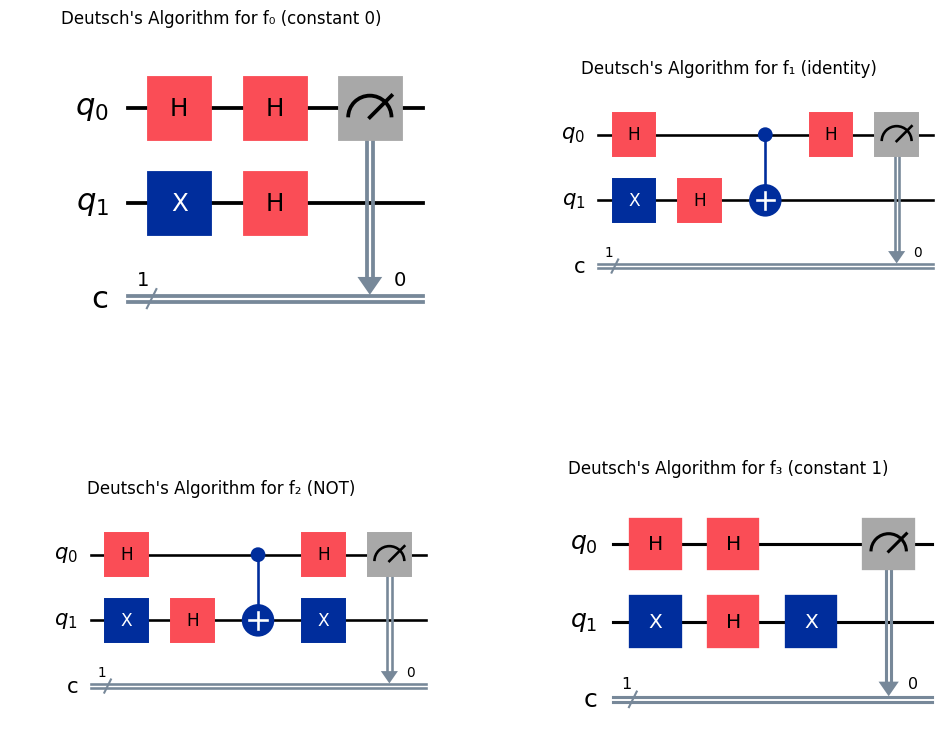

In [14]:
# Visualize Deutsch's algorithm circuit for each oracle
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, (name, oracle) in enumerate(oracles.items()):
				# Create a new quantum circuit for visualization
				vis_qc = qiskit.QuantumCircuit(2, 1)
				vis_qc.h(vis_qc.qubits[:-1])  # Put input qubits in superposition
				vis_qc.x(1)  # Set the second qubit to |1⟩
				vis_qc.h(1)  # Put the second qubit in superposition

				# Resolve oracle circuit safely
				if isinstance(oracle, qiskit.QuantumCircuit):
								oracle_circuit = oracle
				elif callable(oracle):
								# oracle_f* functions take 0 positional args and return a circuit
								oracle_circuit = oracle()
				else:
								oracle_factory = {
												'f₀ (constant 0)': oracle_f0,
												'f₁ (identity)': oracle_f1,
												'f₂ (NOT)': oracle_f2,
												'f₃ (constant 1)': oracle_f3,
								}
								oracle_circuit = oracle_factory[name]()

				# Apply oracle circuit
				vis_qc.compose(oracle_circuit, inplace=True)
				vis_qc.h(0)  # Apply Hadamard to the first qubit again
				vis_qc.measure(0, 0)  # Measure the first qubit

				# Draw the circuit directly on the subplot axis
				vis_qc.draw(output='mpl', ax=axes[i // 2][i % 2])
				axes[i // 2][i % 2].set_title(f"Deutsch's Algorithm for {name}")

## Problem 5: Scaling to the Deutsch–Jozsa Algorithm
The [Deutsch–Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa) generalizes Deutsch's approach to functions with several input bits.
Use [Qiskit](https://www.ibm.com/quantum/qiskit) to create a quantum circuit that can handle the four-bit functions generated in Problem 1.
Explain how the classical function is encoded as a quantum oracle, and demonstrate the use of your circuit on both of the constant functions and any two balanced functions of your choosing.
Show that the circuit correctly identifies the type of each function.

***

### [Add Source Code and Markdown for Problem 5]

## Conclusion

# End of Assessment